# Базовое решение Задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average 20. Permeability (air average mD) – проницаемость

## Считывание данных

In [1]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [133]:
# Считываем тренировочные данные
train = pd.read_csv("oilgas-field-prediction/train_oil.csv")
test = pd.read_csv("oilgas-field-prediction/oil_test.csv")

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [134]:
# Посмотрим как выглядят данные
train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


## Исследование и обработка данных

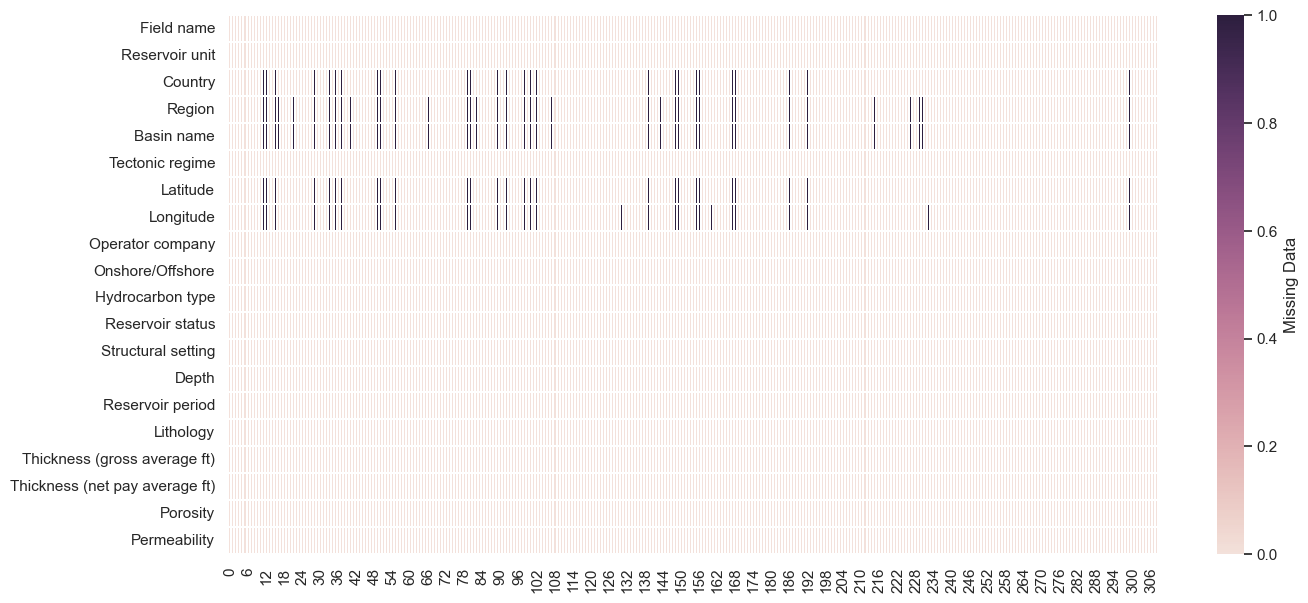

In [135]:
plt.figure(figsize=(15,7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap,
            cbar_kws={'label': 'Missing Data'}, linewidths=0.05)

plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

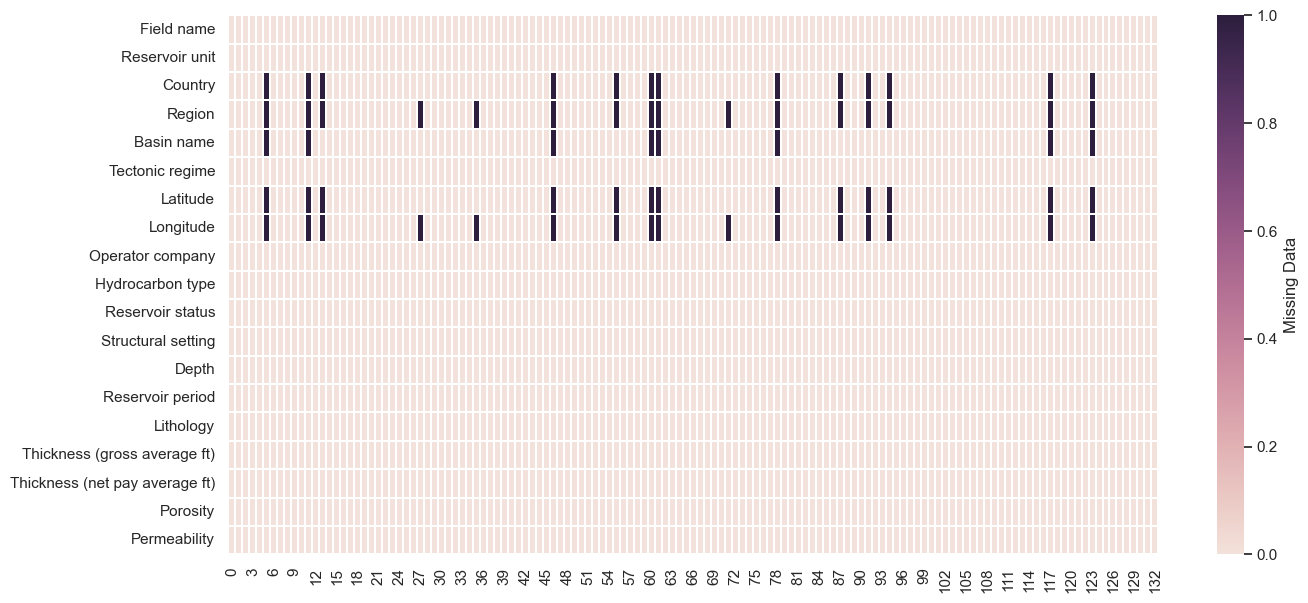

In [136]:
plt.figure(figsize=(15,7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(test.isna().transpose(), cmap=cmap,
            cbar_kws={'label': 'Missing Data'}, linewidths=0.05)

plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

In [137]:
print(train.shape)
train = train.dropna()
print(train.shape)

(309, 20)
(268, 20)


### Обработка категориальных признаков

In [138]:
train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [139]:
train['Tectonic regime'].value_counts()

Tectonic regime
COMPRESSION                                                 57
EXTENSION                                                   26
COMPRESSION/EROSION                                         25
COMPRESSION/EVAPORITE                                       18
INVERSION/COMPRESSION/EXTENSION                             17
EXTENSION/EROSION                                           12
GRAVITY/EXTENSION/EVAPORITE                                 10
COMPRESSION/EVAPORITE/EXTENSION/LINKED                       7
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION                 7
INVERSION/COMPRESSION/EXTENSION/EROSION                      7
INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/BASEMENT-I     5
COMPRESSION/EXTENSION/LINKED                                 4
GRAVITY/EVAPORITE/COMPRESSION                                4
INVERSION/COMPRESSION/EXTENSION/EVAPORITE                    4
GRAVITY/EVAPORITE/EXTENSION                                  4
EXTENSION/EVAPORITE/EROSION/GRAVITY    

In [140]:
train['Tectonic regime'].nunique()

54

In [141]:
# pd.get_dummies()
train['Tectonic regime'].str.get_dummies(sep='/')

# Tectonic_regime_BASEMENT-I

,BASEMENT-I,COMPRESSION,DIAPIR,EROSION,EVAPORITE,EXTENSION,GRAVITY,INVERSION,LINKED,REACTIVATION,SHALE,STRIKE-SLIP,SYNSEDIMENTATION,TRANSPRESSION,TRANSTENSION,UPLIFT
0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
305,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0
306,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
307,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Как мы видим в колонке 'Tectonic regime' множество разных категорий, причем одному объекту может соответствовать несколько категорий сразу.

Встает вопрос как обработать такие признаки.

In [142]:
train['Structural setting'].value_counts()

Structural setting
FORELAND                      67
RIFT                          43
INTRACRATONIC                 27
THRUST                        14
PASSIVE MARGIN                12
SALT/FORELAND                 11
SALT/PASSIVE MARGIN            9
INVERSION/RIFT                 7
DELTA/PASSIVE MARGIN           7
INVERSION/BACKARC              6
SALT/INVERSION/RIFT            5
DELTA/SALT/PASSIVE MARGIN      5
THRUST/FORELAND                4
SUB-THRUST/FORELAND            4
RIFT/SALT                      4
RIFT/INVERSION                 3
SUB-SALT/RIFT                  3
SUB-SALT/FORELAND              3
WRENCH                         3
BACKARC                        3
SALT/RIFT                      2
FORELAND/SALT                  2
FORELAND/THRUST                2
THRUST/SUB-THRUST/FORELAND     2
SUB-SALT/INVERSION             2
SUB-THRUST                     2
WRENCH/DELTA                   2
SUB-SALT                       1
INVERSION/FORELAND             1
RIFT/PASSIVE MARGIN     

In [143]:
train['Basin name'].value_counts().head(50)

Basin name
WESTERN CANADA                      24
GULF OF MEXICO NORTHERN ONSHORE     19
NORTH SEA CENTRAL                   14
NORTH SEA NORTHERN                  12
PERMIAN                             10
WILLISTON                           10
BOHAI                                8
ANADARKO                             7
SIBERIAN WESTERN                     7
RUB AL KHALI                         6
POWDER RIVER                         6
THE GULF                             5
JIUQUAN                              4
MID-NORWAY SHELF                     4
CAMBAY                               4
PARIS                                4
GIPPSLAND                            4
GREATER GREEN RIVER                  4
EASTERN VENEZUELA                    4
CASPIAN SOUTH                        4
SIBERIAN EASTERN                     4
JEANNE D ARC                         3
PARADOX                              3
NIGER DELTA                          3
VOLGA-URAL                           3
FAHUD SALT    

In [144]:
train['Region'].value_counts()

Region
NORTH AMERICA          110
FAR EAST                46
EUROPE                  38
FORMER SOVIET UNION     25
MIDDLE EAST             20
AFRICA                  17
LATIN AMERICA           12
Name: count, dtype: int64

In [145]:
train['Hydrocarbon type'].value_counts()

Hydrocarbon type
OIL               200
GAS                40
GAS-CONDENSATE     26
CARBON DIOXIDE      2
Name: count, dtype: int64

In [146]:
train['Field name'].value_counts()

Field name
ERSKINE             3
LAOJUNMIAO          3
ELK BASIN           2
HIBERNIA            2
SAIH RAWL           2
                   ..
SHANSHAN            1
HUTTON NORTHWEST    1
WANGCHANG           1
IAGIFU-HEDINIA      1
WELL DRAW           1
Name: count, Length: 251, dtype: int64

In [147]:
train['Reservoir unit'].value_counts()

Reservoir unit
BRENT                      8
SAN ANDRES                 6
SHUAIBA                    5
TOR-EKOFISK                4
RED SERIES                 3
                          ..
WILCOX (G SAND)            1
SANJIANFANG                1
QIANJIANG                  1
TORO                       1
MESAVERDE (TEAPOT SAND)    1
Name: count, Length: 225, dtype: int64

In [148]:
train['Country'].value_counts()

Country
USA                    77
CANADA                 33
CHINA                  19
UK                     19
RUSSIA                 16
NORWAY                 11
INDONESIA               9
AUSTRALIA               7
OMAN                    6
EGYPT                   6
BRAZIL                  5
FRANCE                  5
TURKMENISTAN            5
UAE                     4
INDIA                   4
VENEZUELA               4
QATAR                   3
KAZAKHSTAN              3
NIGERIA                 2
TUNISIA                 2
PAPUA NEW GUINEA        2
NEUTRAL ZONE            2
SAUDI ARABIA            2
MALAYSIA                2
LIBYA                   2
COLOMBIA                2
THAILAND                2
TUNISIA /ALGERIA        1
IRAQ                    1
DENMARK                 1
SOUTH AFRICA            1
AFGHANISTAN             1
TURKEY                  1
EQUATORIAL GUINEA       1
GABON                   1
UK /NORWAY              1
IRAN                    1
TRINIDAD AND TOBAGO     1
UZBE

In [149]:
train['Operator company'].value_counts().head(50)

Operator company
NUMEROUS                              26
CHEVRON                               15
PETROCHINA                            14
SHELL                                  9
BP                                     9
CONOCOPHILLIPS                         8
STATOILHYDRO                           8
EXXONMOBIL                             8
PDO                                    6
PETROBRAS                              5
AMERADA HESS                           5
ONGC                                   4
EXXONMOBIL /BHP BILLITON               4
CNOOC                                  3
TURKMENNEFT                            3
HUSKY ENERGY                           3
BP AND OTHERS                          3
OCCIDENTAL                             3
IMPERIAL OIL RESOURCES                 3
TALISMAN                               3
LNOC                                   2
HIBERNIA MANAGEMENT DEVELOPMENT CO     2
BAPETCO                                2
ARABIAN OIL CO                         2

/var/folders/_p/8krn6b1j21bbrx339d1x74z80000gn/T/ipykernel_89005/1738316304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train['Hydrocarbon type'], ax=ax[0], palette='hls')
/var/folders/_p/8krn6b1j21bbrx339d1x74z80000gn/T/ipykernel_89005/1738316304.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train['Onshore/Offshore'], ax=ax[1], palette='hls')
/var/folders/_p/8krn6b1j21bbrx339d1x74z80000gn/T/ipykernel_89005/1738316304.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


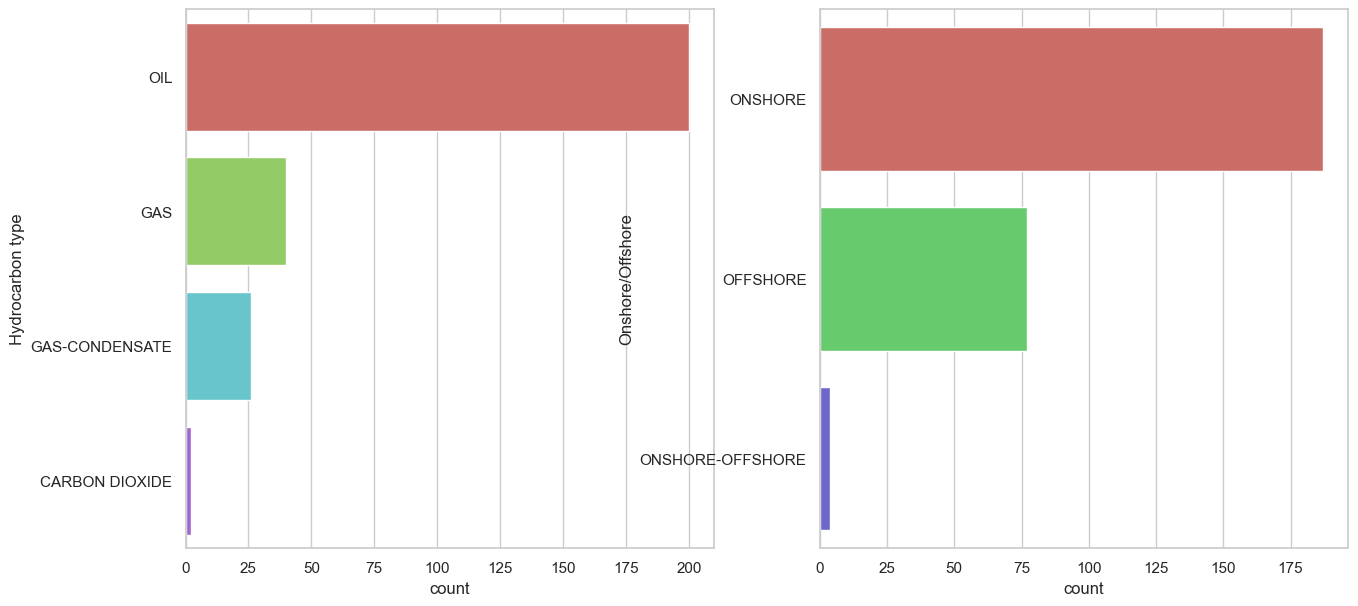

In [150]:
sns.set_theme(style="white")
sns.set_theme(style="whitegrid", color_codes=True)

fig, ax = plt.subplots(1,2, figsize=(15, 7))

sns.countplot(train['Hydrocarbon type'], ax=ax[0], palette='hls')
sns.countplot(train['Onshore/Offshore'], ax=ax[1], palette='hls')
fig.show()

In [151]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             187
OFFSHORE             77
ONSHORE-OFFSHORE      4
Name: count, dtype: int64

## Обработка данных

In [152]:
def fill_dummies(train, test, column_name: str, sep = '/'):
    train_dummies = train[column_name].str.get_dummies(sep=sep).add_prefix(column_name)
    test_dummies = test[column_name].str.get_dummies(sep=sep).add_prefix(column_name)

    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    train = pd.concat([train, train_dummies], axis=1)
    test = pd.concat([test, test_dummies], axis=1)

    return train, test

In [153]:
train, test = fill_dummies(train, test, 'Tectonic regime', sep='/')
train, test = fill_dummies(train, test, 'Structural setting', sep='/')

In [154]:
# Count the occurrences of each category in 'Lithology'
counts = train['Lithology'].value_counts()
counts1 = test['Lithology'].value_counts()
# Identify categories with counts less than 10
rare_categories = counts[counts < 10].index
rare_categories1 = counts1[counts1 < 10].index
# Replace rare categories with 'Other'
train['Lithology'] = train['Lithology'].replace(rare_categories, 'Other')
test['Lithology'] = test['Lithology'].replace(rare_categories1, 'Other')

In [155]:
train['Lithology'].value_counts()

Lithology
SANDSTONE    160
Other         39
DOLOMITE      37
LIMESTONE     32
Name: count, dtype: int64

In [156]:
train = train.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])
test = test.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])

train.head()

,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),...,Structural settingFORELAND,Structural settingINTRACRATONIC,Structural settingINVERSION,Structural settingPASSIVE MARGIN,Structural settingRIFT,Structural settingSALT,Structural settingSUB-SALT,Structural settingSUB-THRUST,Structural settingTHRUST,Structural settingWRENCH
0,51.0000,44.8042,ONSHORE,OIL,DECLINING PRODUCTION,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,...,1,0,0,0,0,0,0,0,0,0
1,-19.6017,-39.8332,ONSHORE,OIL,NEARLY DEPLETED,4843,PALEOGENE,SANDSTONE,2133.0,72.0,...,0,0,0,1,0,0,0,0,0,0
2,26.0800,49.8100,ONSHORE,OIL,REJUVENATING,6050,JURASSIC,LIMESTONE,250.0,184.0,...,1,0,0,0,0,0,0,0,0,0
3,61.3833,1.7500,OFFSHORE,OIL,NEARLY DEPLETED,8988,JURASSIC,SANDSTONE,425.0,300.0,...,0,0,0,0,1,0,0,0,0,0
4,53.2287,-115.8008,ONSHORE,OIL,UNKNOWN,9306,DEVONIAN,DOLOMITE,233.0,167.0,...,1,0,0,0,0,0,0,0,0,0


Остальные категориальные признаки устроены проще и к ним можно применить обычные методы кодирования, которые мы изучали до этого.

Применим к ним кодировщик LabelEncoder().

In [157]:
from sklearn.preprocessing import OrdinalEncoder

# Список категориальных столбцов
categ = ['Hydrocarbon type', 'Reservoir status', 'Reservoir period', 'Lithology']

# Создаем OrdinalEncoder, обрабатываем неизвестные категории специальным значением -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Обучаем на тренировочных данных и преобразуем сразу train и test
# train.csv - train_X/test_X
# test.csv - test

# train_X = train.copy()
# test_X = train.copy()

# train_encoded = encoder.fit_transform(train_X[categ])
# train_encoded = encoder.transform(test_X[categ])

train_encoded = encoder.fit_transform(train[categ])
test_encoded = encoder.transform(test[categ])

# Заменяем старые категориальные столбцы новыми закодированными
train[categ] = train_encoded
test[categ] = test_encoded

In [158]:
train

,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),...,Structural settingFORELAND,Structural settingINTRACRATONIC,Structural settingINVERSION,Structural settingPASSIVE MARGIN,Structural settingRIFT,Structural settingSALT,Structural settingSUB-SALT,Structural settingSUB-THRUST,Structural settingTHRUST,Structural settingWRENCH
0,51.0000,44.8042,ONSHORE,3.0,2.0,1870,1.0,3.0,262.0,33.0,...,1,0,0,0,0,0,0,0,0,0
1,-19.6017,-39.8332,ONSHORE,3.0,6.0,4843,13.0,3.0,2133.0,72.0,...,0,0,0,1,0,0,0,0,0,0
2,26.0800,49.8100,ONSHORE,3.0,8.0,6050,8.0,1.0,250.0,184.0,...,1,0,0,0,0,0,0,0,0,0
3,61.3833,1.7500,OFFSHORE,3.0,6.0,8988,8.0,3.0,425.0,300.0,...,0,0,0,0,1,0,0,0,0,0
4,53.2287,-115.8008,ONSHORE,3.0,12.0,9306,5.0,0.0,233.0,167.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,-6.0136,142.8409,ONSHORE,2.0,1.0,9905,9.0,3.0,490.0,240.0,...,0,0,0,0,0,0,0,0,1,0
305,76.4462,-108.9172,ONSHORE,1.0,11.0,3390,8.0,3.0,100.0,71.0,...,1,0,0,0,0,0,0,0,0,0
306,40.3000,-110.2100,ONSHORE,3.0,5.0,15250,13.0,3.0,8000.0,575.0,...,1,0,0,0,0,0,0,0,0,0
307,45.1039,-105.0967,ONSHORE,3.0,6.0,4300,3.0,3.0,45.0,23.0,...,1,0,0,0,0,0,0,0,0,0


In [159]:
test

,Latitude,Longitude,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,...,Structural settingFORELAND,Structural settingINTRACRATONIC,Structural settingINVERSION,Structural settingPASSIVE MARGIN,Structural settingRIFT,Structural settingSALT,Structural settingSUB-SALT,Structural settingSUB-THRUST,Structural settingTHRUST,Structural settingWRENCH
0,29.7422,28.4925,2.0,5.0,10282,3.0,3.0,745.0,144.0,10.0,...,0,0,0,0,1,0,0,0,0,0
1,31.4382,31.3616,1.0,2.0,10499,11.0,3.0,509.0,410.0,20.0,...,0,0,0,0,0,0,0,0,0,1
2,48.4740,57.6667,3.0,4.0,6000,1.0,1.0,300.0,105.0,10.0,...,1,0,0,0,0,0,1,0,0,0
3,60.7833,1.7333,3.0,6.0,9790,8.0,3.0,886.0,344.0,17.0,...,0,0,0,0,1,0,0,0,0,0
4,21.6000,72.9167,3.0,5.0,2950,13.0,3.0,670.0,0.0,21.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,37.9167,118.4333,3.0,6.0,5970,12.0,0.0,560.0,82.0,2.5,...,0,0,0,0,1,0,0,0,0,0
129,35.0461,-119.1904,3.0,6.0,11100,11.0,2.0,200.0,150.0,20.0,...,0,0,0,0,0,0,0,0,0,1
130,38.2100,117.0600,3.0,5.0,5384,13.0,3.0,230.0,69.0,26.7,...,0,0,0,0,1,0,0,0,0,0
131,38.2100,117.0600,3.0,2.0,4721,13.0,3.0,164.0,62.0,23.2,...,0,0,0,0,1,0,0,0,0,0


In [160]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Onshore/Offshore'] = le.fit_transform(train['Onshore/Offshore'])

train

,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),...,Structural settingFORELAND,Structural settingINTRACRATONIC,Structural settingINVERSION,Structural settingPASSIVE MARGIN,Structural settingRIFT,Structural settingSALT,Structural settingSUB-SALT,Structural settingSUB-THRUST,Structural settingTHRUST,Structural settingWRENCH
0,51.0000,44.8042,1,3.0,2.0,1870,1.0,3.0,262.0,33.0,...,1,0,0,0,0,0,0,0,0,0
1,-19.6017,-39.8332,1,3.0,6.0,4843,13.0,3.0,2133.0,72.0,...,0,0,0,1,0,0,0,0,0,0
2,26.0800,49.8100,1,3.0,8.0,6050,8.0,1.0,250.0,184.0,...,1,0,0,0,0,0,0,0,0,0
3,61.3833,1.7500,0,3.0,6.0,8988,8.0,3.0,425.0,300.0,...,0,0,0,0,1,0,0,0,0,0
4,53.2287,-115.8008,1,3.0,12.0,9306,5.0,0.0,233.0,167.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,-6.0136,142.8409,1,2.0,1.0,9905,9.0,3.0,490.0,240.0,...,0,0,0,0,0,0,0,0,1,0
305,76.4462,-108.9172,1,1.0,11.0,3390,8.0,3.0,100.0,71.0,...,1,0,0,0,0,0,0,0,0,0
306,40.3000,-110.2100,1,3.0,5.0,15250,13.0,3.0,8000.0,575.0,...,1,0,0,0,0,0,0,0,0,0
307,45.1039,-105.0967,1,3.0,6.0,4300,3.0,3.0,45.0,23.0,...,1,0,0,0,0,0,0,0,0,0


Heatmap позволяет визуадизировать матрицу корреляции между данными.

Корреляция - важнейший фактор, лежащий в основе анализа данных. Он сообщает, как переменные в наборе данных связаны друг с другом и как они перемещаются относительно друг друга. Значение корреляции колеблется от -1 до +1. 0 Корреляция означает, что две переменные не зависят друг от друга. Положительная корреляция указывает на то, что переменные движутся в одном направлении, а отрицательная корреляция указывает на противоположное.

<Axes: >

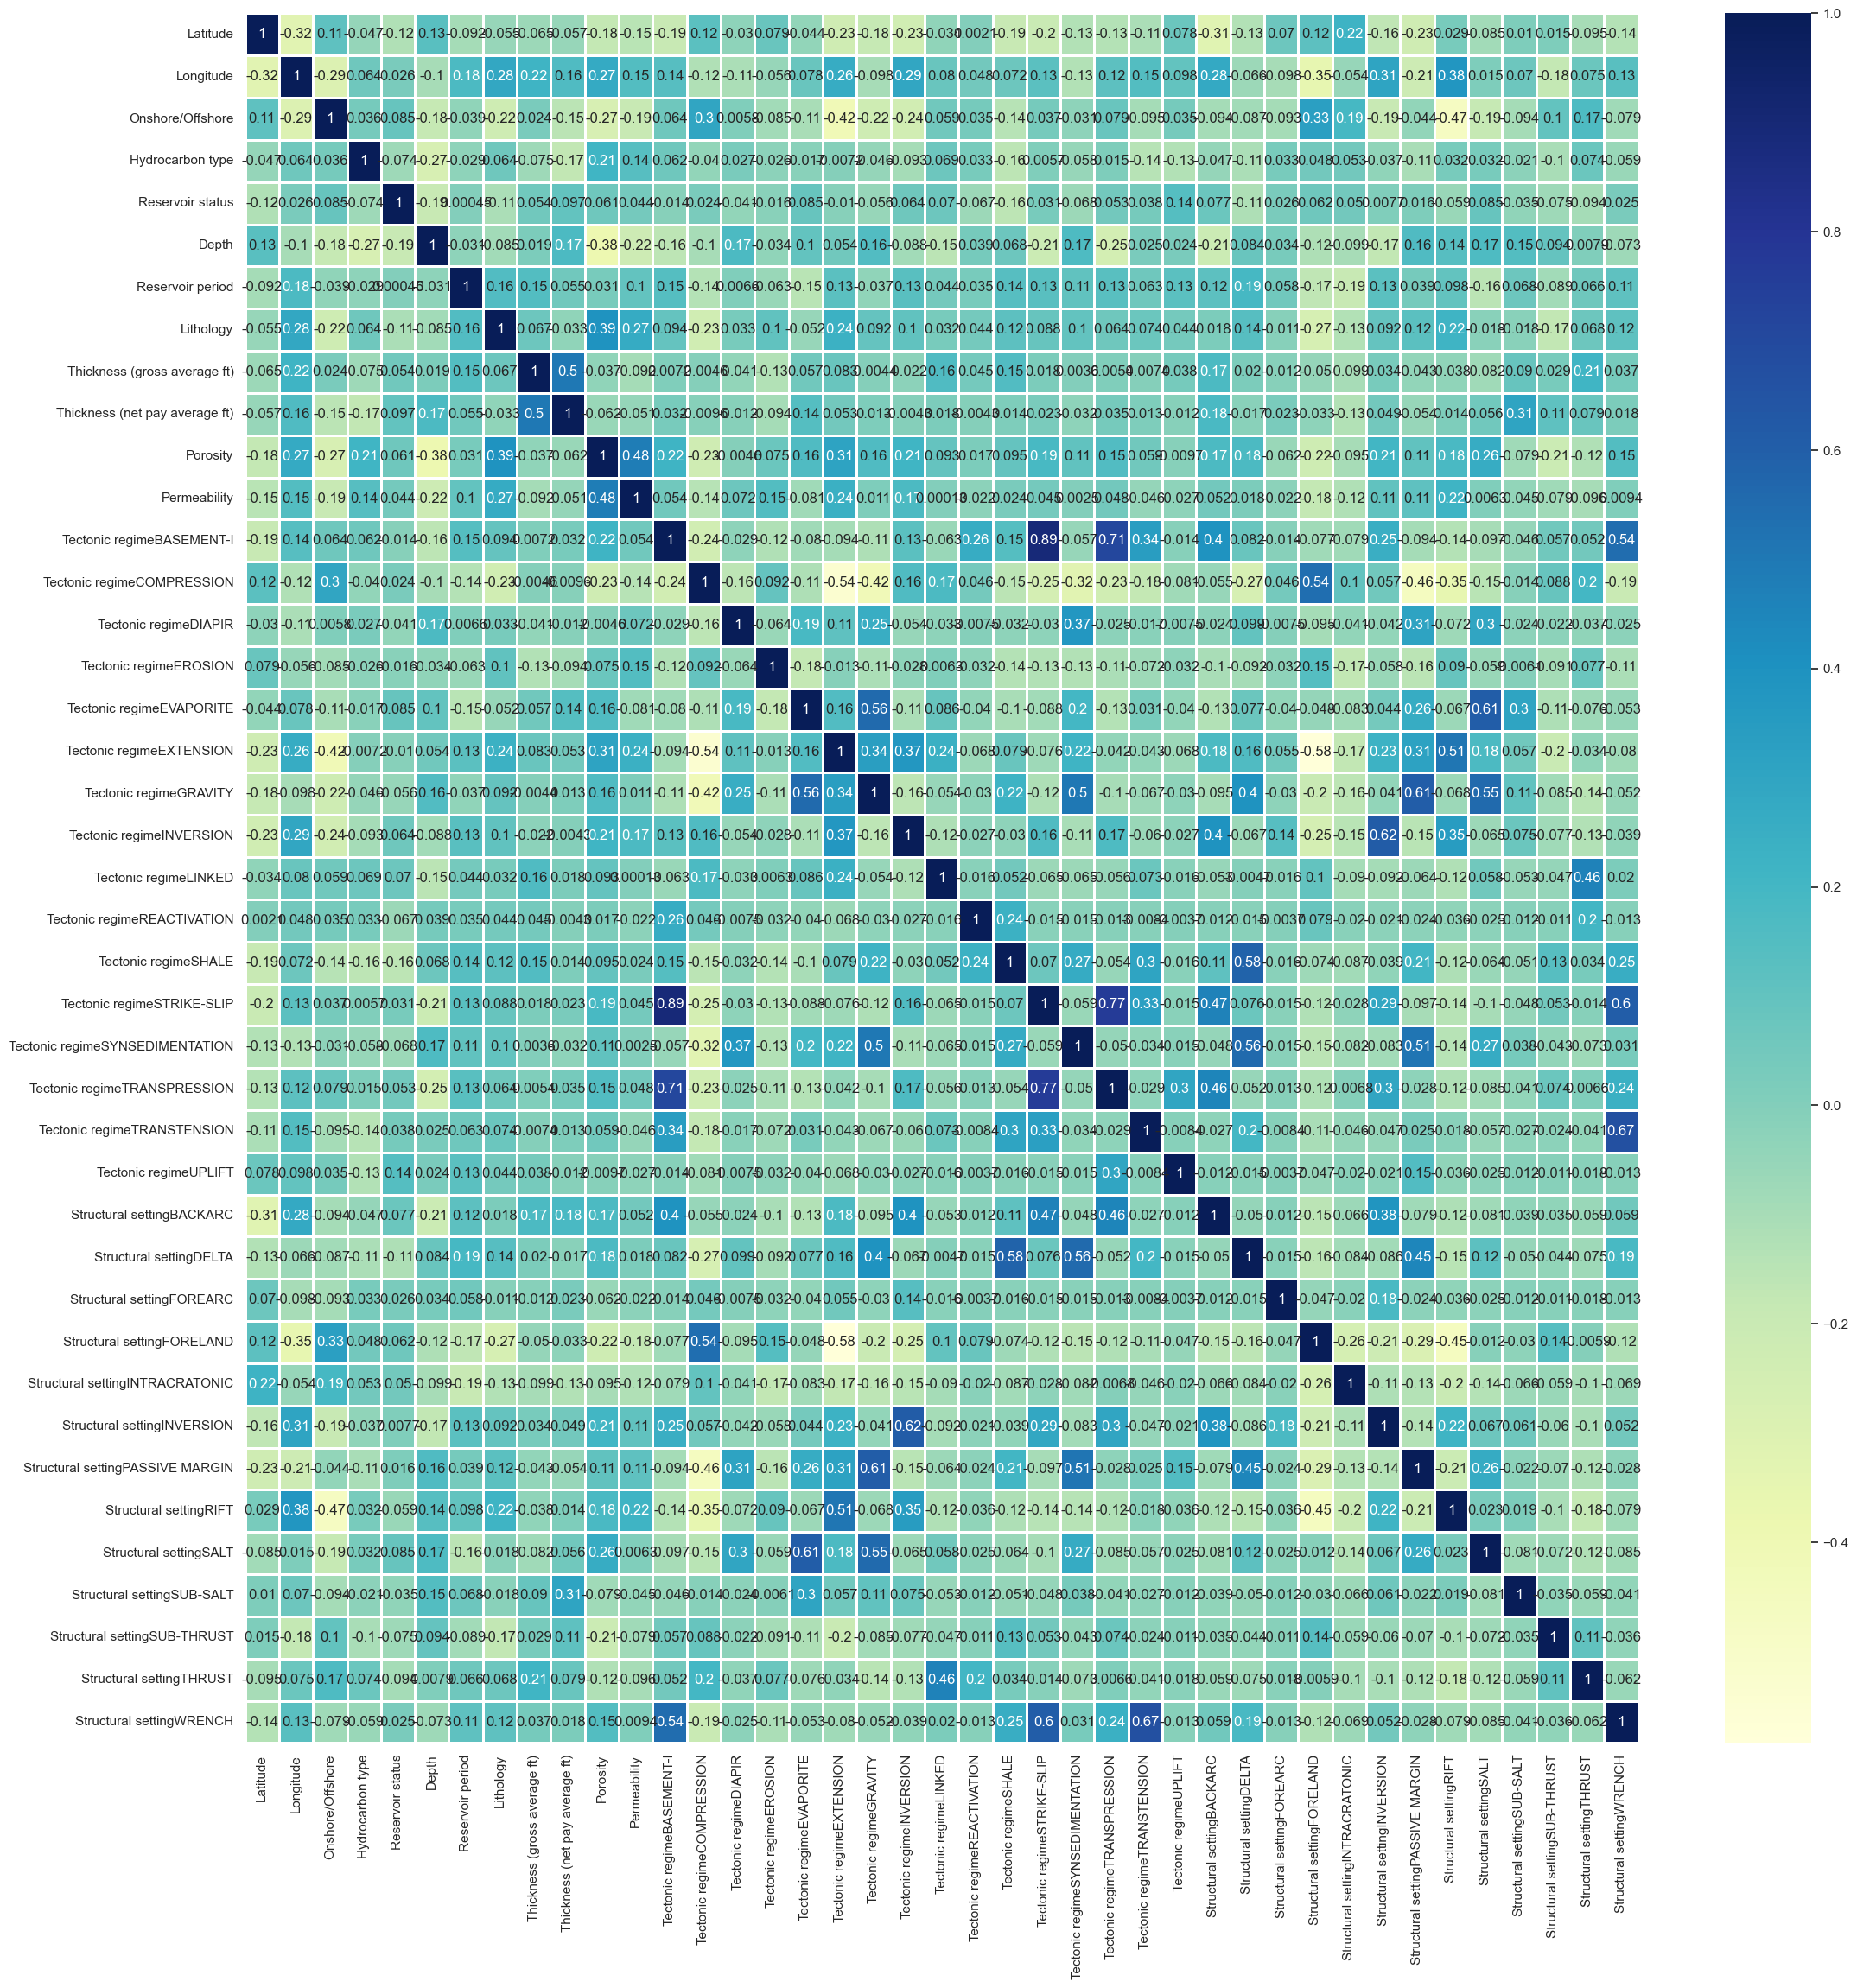

In [161]:
sns.set_theme(rc = {'figure.figsize':(26, 26)})

sns.heatmap(train.corr(), annot = True, cmap="YlGnBu", linecolor='white',linewidths=1)

# plt.savefig("heatmap.png")

По сути, это сетка цветных квадратов , где каждый квадрат, или bin , отмечает пересечение значений двух переменных, которые простираются вдоль горизонтальной и вертикальной осей.

Цветовые палитры: https://seaborn.pydata.org/tutorial/color_palettes.html

Информация о HeatMap: https://seaborn.pydata.org/generated/seaborn.heatmap.html


In [162]:
# train_X.columns
# test_X.columns

# len(set(train_X.columns) & set(test_X.columns)) == len(train_X.columns)

In [163]:
# sns.set()
# columns = ['Onshore/Offshore', 'Reservoir status', 'Depth', 'Lithology_CHALK', 'Reservoir period_CRETACEOUS-PALEOGENE',
#            'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability', 'Region', 'Latitude', 'Longitude']

# sns.pairplot(train[columns], size = 4, kind ='scatter', diag_kind='kde')
# plt.show()

# plt.savefig("pairplot.png")

In [164]:
# sns.set()
# columns = ['Region', 'Latitude', 'Longitude']

# sns.pairplot(train[columns], kind ='scatter', diag_kind='kde')
# plt.show()

In [165]:
# sns.set()
# columns = ['Reservoir period_MESOZOIC', 'Lithology_VOLCANICS']

# sns.pairplot(train[columns], kind ='scatter', diag_kind='kde')
# plt.show()

Посмотрим на баланс классов.

/var/folders/_p/8krn6b1j21bbrx339d1x74z80000gn/T/ipykernel_89005/1937567357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Onshore/Offshore', data=y_data, palette='hls')


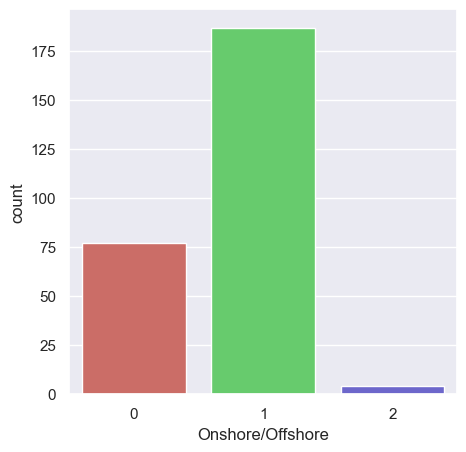

In [166]:
sns.set_theme(rc = {'figure.figsize':(5,5)})
y_data = pd.DataFrame(train['Onshore/Offshore'])
sns.countplot(x='Onshore/Offshore', data=y_data, palette='hls')
plt.show()

In [167]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
1    187
0     77
2      4
Name: count, dtype: int64

In [168]:
# train.head()

In [169]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 308
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Latitude                          268 non-null    float64
 1   Longitude                         268 non-null    float64
 2   Onshore/Offshore                  268 non-null    int64  
 3   Hydrocarbon type                  268 non-null    float64
 4   Reservoir status                  268 non-null    float64
 5   Depth                             268 non-null    int64  
 6   Reservoir period                  268 non-null    float64
 7   Lithology                         268 non-null    float64
 8   Thickness (gross average ft)      268 non-null    float64
 9   Thickness (net pay average ft)    268 non-null    float64
 10  Porosity                          268 non-null    float64
 11  Permeability                      268 non-null    float64
 12  Tectonic regi

In [170]:
# 'Tectonic regimeBASEMENT-I',
# 'Tectonic regimeCOMPRESSION', 'Tectonic regimeDIAPIR',
# 'Tectonic regimeEROSION', 'Tectonic regimeEVAPORITE',
# 'Tectonic regimeGRAVITY', 'Tectonic regimeINVERSION', 'Tectonic regimeLINKED',
# 'Tectonic regimeREACTIVATION', 'Tectonic regimeSHALE',
# 'Tectonic regimeSTRIKE-SLIP', 'Tectonic regimeSYNSEDIMENTATION',
# 'Tectonic regimeTRANSPRESSION', 'Tectonic regimeTRANSTENSION',
# 'Tectonic regimeUPLIFT', 'Structural settingBACKARC',
# 'Structural settingDELTA', 'Structural settingFOREARC',
# 'Structural settingFORELAND', 'Structural settingINTRACRATONIC',
# 'Structural settingINVERSION', 'Structural settingPASSIVE MARGIN',
# 'Structural settingRIFT', 'Structural settingSALT',
# 'Structural settingSUB-SALT', 'Structural settingSUB-THRUST',
# 'Structural settingTHRUST', 'Structural settingWRENCH'

# train = train[['Latitude', 'Longitude','Tectonic regimeEXTENSION', 'Onshore/Offshore',
#        'Depth', 'Lithology', 'Thickness (gross average ft)', 
#        'Thickness (net pay average ft)', 'Porosity', 'Permeability']]



# test = test[['Latitude', 'Longitude','Tectonic regimeEXTENSION',
#        'Depth', 'Lithology', 'Thickness (gross average ft)', 
#        'Thickness (net pay average ft)', 'Porosity', 'Permeability']]

## Обучение модели

In [171]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['Onshore/Offshore'])
y = train['Onshore/Offshore']

# Разбиваем данные с учетом стратификации
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% данных в тест
    random_state=42,         # Фиксируем для воспроизводимости
    stratify=y               # Стратифицированное разбиение
)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (214, 40), (214,)
Test dataset size: (54, 40), (54,)


In [172]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier

# Создадим модель дерева решений
# tree = DecisionTreeClassifier(max_depth=5, random_state=42,max_leaf_nodes=10)
# knn = KNeighborsClassifier(2)

# обучение модели
# tree.fit(X_train, y_train)
# knn.fit(X_train, y_train)

# предсказание ответов для тестовой выборки
# y_pred_tree = tree.predict(X_test)
# y_pred_knn = knn.predict(X_test)

In [173]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint

# Базовая модель
tree = DecisionTreeClassifier(random_state=42)

# Диапазоны гиперпараметров для случайного поиска
param_dist = {
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_leaf_nodes': randint(5, 50),
    'criterion': ['gini', 'entropy', 'log_loss']
}

# Настройка RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_dist,
    n_iter=50,              # сколько случайных комбинаций попробовать
    cv=5,                   # кросс-валидация на 5 фолдов
    scoring='accuracy',     # метрика (можно заменить, например, на 'f1_macro')
    random_state=42,
    n_jobs=-1               # использовать все ядра
)

# Запуск подбора
random_search.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:", random_search.best_params_)

# Лучшая модель
best_tree = random_search.best_estimator_

# Предсказания
y_pred_tree = best_tree.predict(X_test)

# Оценка
from sklearn.metrics import accuracy_score
print("Accuracy на тесте:", accuracy_score(y_test, y_pred_tree))


Лучшие параметры: {'criterion': 'log_loss', 'max_depth': 11, 'max_leaf_nodes': 39, 'min_samples_leaf': 7, 'min_samples_split': 17}
Accuracy на тесте: 0.7777777777777778


/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


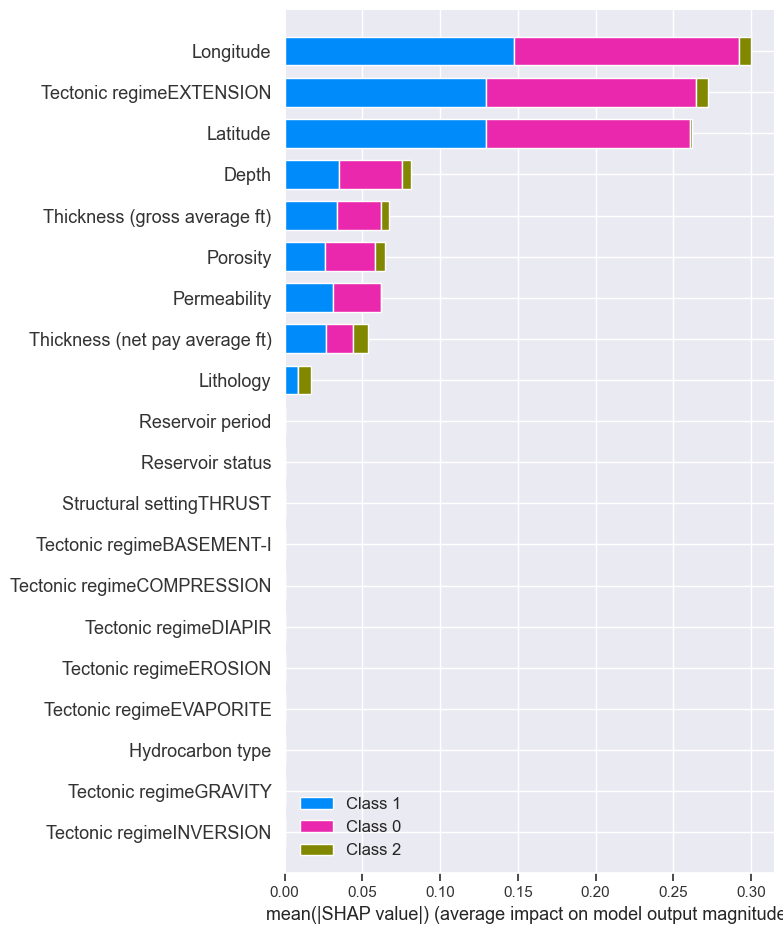

In [174]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

explainer = shap.Explainer(best_tree)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


In [175]:
y_test.value_counts()

Onshore/Offshore
1    38
0    15
2     1
Name: count, dtype: int64

In [176]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# answers_pred - ответы которые вернула модель для X_test
# y_test - это правильные ответы для X_test
print(f'Accuracy: {accuracy_score(y_test, y_pred_tree)}')
print(f'Precision: {precision_score(y_test, y_pred_tree, average="macro")}')
print(f'Recall: {recall_score(y_test, y_pred_tree, average="macro")}')
# print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)}')

Accuracy: 0.7777777777777778
Precision: 0.48205128205128206
Recall: 0.4894736842105263


/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [177]:
import numpy as np

np.unique(y_train)

array([0, 1, 2])

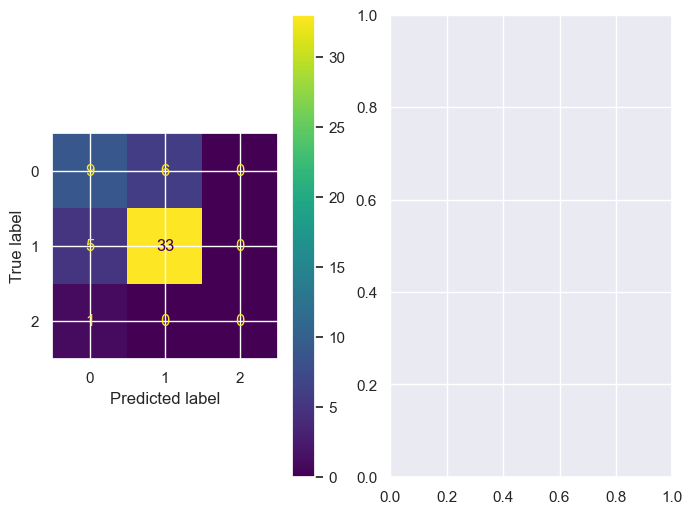

In [178]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
# conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1,2,figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix_tree, display_labels=best_tree.classes_)
display.plot(ax=axes[0])

# display = ConfusionMatrixDisplay(conf_matrix_knn, display_labels=knn.classes_)
# display.plot(ax=axes[1])

In [179]:
y_test_pred = best_tree.predict(test)
ans_df = pd.DataFrame(y_test_pred, columns=['Onshore/Offshore'])

In [180]:
ans_df['Onshore/Offshore'] = le.inverse_transform(ans_df['Onshore/Offshore'])

In [181]:
ans_df.head()

,Onshore/Offshore
0,OFFSHORE
1,ONSHORE
2,ONSHORE
3,OFFSHORE
4,ONSHORE


In [182]:
ans_df.reset_index(inplace=True)
ans_df.to_csv('predict.csv', index=False)